In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

In [25]:
# Load the data
data = pd.read_csv('clean_finished_paths.csv')

print(data.shape)
print(data.columns)

(70860, 13)
Index(['hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
       'nb_clicks', 'nb_back_clicks', 'path_length', 'source', 'target',
       'source_category', 'target_category', 'shortest_path'],
      dtype='object')


In [21]:
data.describe()

,durationInSec,rating,nb_clicks,nb_back_clicks,path_length,shortest_path
count,70860.000000,70860.000000,70860.000000,70860.000000,70860.000000,70860.000000
mean,157.010034,0.795315,5.692196,0.388061,5.304135,2.799125
std,365.047285,1.814260,4.779301,1.401045,3.941106,0.697676
min,1.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
25%,59.000000,-1.000000,3.000000,0.000000,3.000000,2.000000
50%,106.000000,1.000000,5.000000,0.000000,5.000000,3.000000
75%,182.000000,2.000000,7.000000,0.000000,6.000000,3.000000
max,35091.000000,5.000000,434.000000,45.000000,419.000000,6.000000


In [22]:
# Weird stuff
data[data["shortest_path"] == -1]

,hashedIpAddress,timestamp,durationInSec,path,rating,nb_clicks,nb_back_clicks,path_length,source,target,source_category,target_category,shortest_path
2995,5f22535607b1d77d,2012-11-26 16:03:08,3,"['Bird', 'Wikipedia_Text_of_the_GNU_Free_Docum...",-1,1,0,1,Bird,Wikipedia_Text_of_the_GNU_Free_Documentation_L...,"['Science', 'Biology', 'Birds']","['IT', 'Websites_and_the_Internet']",-1


In [ ]:
# Get most frequent sources and targets
freq_src = data["source"].value_counts()[:50]
freq_trgt = data["target"].value_counts()[:50]

# Get lists of most frequent sources and targets
top_sources = freq_src.index.tolist()
top_targets = freq_trgt.index.tolist()

# Filter paths that have a source or target in the top lists
subset = data[(data["source"].isin(top_sources)) | (data["target"].isin(top_targets))]

# Check subset size 
print("Subset size:", len(subset))

# Save subset to a new csv
subset.to_csv("subset.csv", index=False)


Subset size: 17315


In [38]:
# Load the subset
data = pd.read_csv('subset.csv')

# Initialize a directed graph
G = nx.DiGraph()

# Add edges from the data: each edge goes from 'source' to 'target'
# NetworkX will automatically create nodes when you add edges
for _, row in data.iterrows():
    source = row['source']
    target = row['target']
    G.add_edge(source, target)

# Print basic info about the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

Number of nodes: 1527
Number of edges: 2231
Average degree: 2.9220694171578256


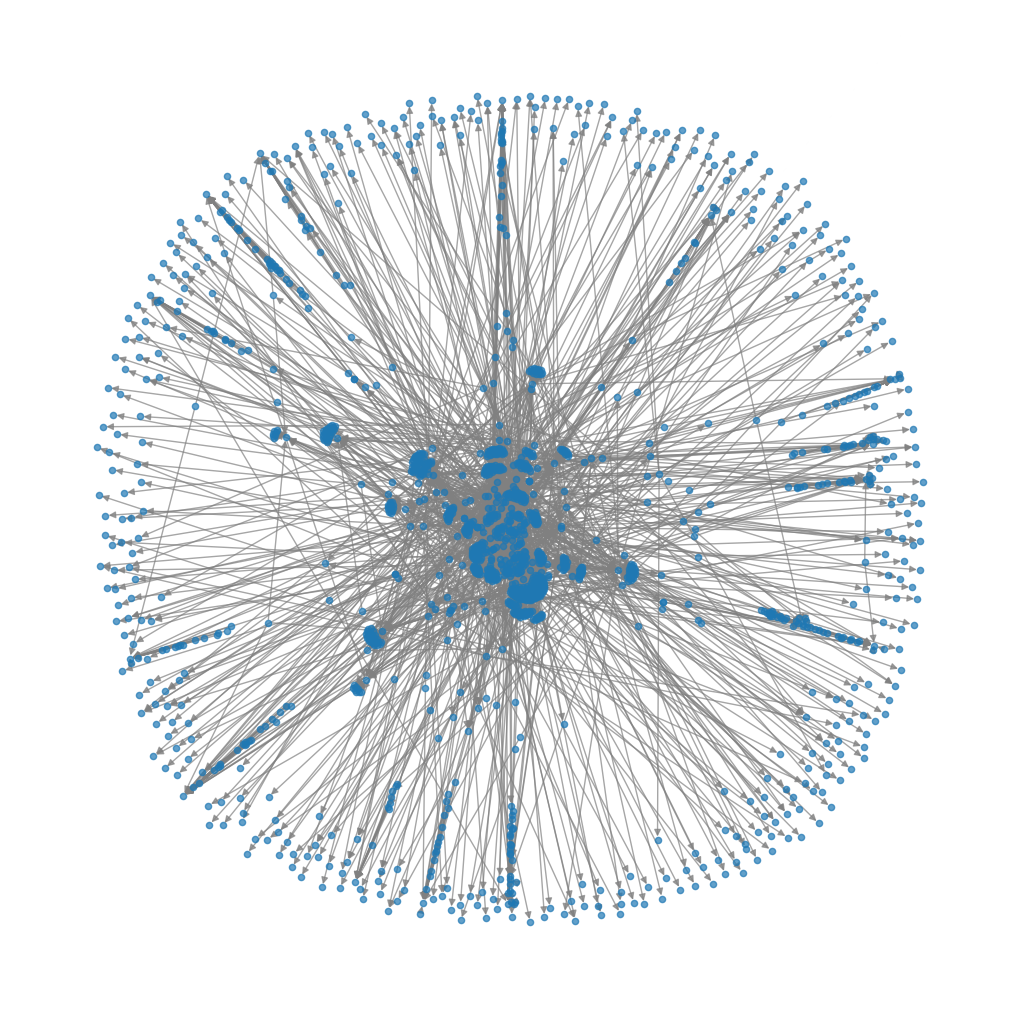

In [40]:
# Visualize the graph
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=False, node_size=20, font_size=8, edge_color='gray', alpha=0.7)
plt.show()